# 📊 **Projeto de Machine Learning - Previsão do Nível de Obesidade**

| Seção | Descrição |
|------|--------|
| 🎯 **Objetivo**| Desenvolver um modelo de Machine Learning capaz de prever o nível de obesidade de indivíduos com base em características demográficas, hábitos alimentares e estilo de vida. |
| 📂 **Fonte dos Dados** | Base de dados em formato CSV contendo informações de entrevistados, incluindo variáveis como idade, peso, altura, hábitos alimentares, atividade física e comportamento. |
| 🧠 **Problema de ML** | Classificação multiclasse (prever categorias de nível de obesidade). |
| 🎯 **Variável Alvo** | `Obesity_level` |
| 🔍 **Estratégia** | Aplicar técnicas de Feature Engineering, Encoding de variáveis categóricas e seleção de atributos para melhorar a performance do modelo. |
| ⚙️ **Modelos Avaliados** | Serão testados algoritmos como Regressão Logística, Random Forest e XGBoost para comparação de desempenho. |
| 📏 **Métricas de Avaliação** | Acurácia, Precision, Recall e F1-Score para avaliar a qualidade das previsões. |
| 🛠️ **Etapas do Projeto** | 1. Análise exploratória (EDA) <br> 2. Tratamento de dados <br> 3. Feature Engineering <br> 4. Treinamento de modelos <br> 5. Avaliação e validação |
| 🚀 **Resultado Esperado** | Construir um modelo robusto, com boa capacidade de generalização, capaz de prever corretamente o nível de obesidade em novos dados. |

# **📒Dicionário de Dados:**
Dicionário de dados:
* Gender: Gênero.
* Age: Idade.
* Height:Altura em metros.
* Weight: Peso em kgs.
* family_history: Algum membro da família sofreu ou sofre de excesso de peso?
* FAVC: Você come alimentos altamente calóricos com frequência?
* FCVC: Você costuma comer vegetais nas suas refeições?
* NCP: Quantas refeições principais você faz diariamente?
* CAEC: Você come alguma coisa entre as refeições?
* SMOKE: Você fuma?
* CH2O: Quanta água você bebe diariamente?
* SCC: Você monitora as calorias que ingere diariamente?
* FAF: Com que frequência você pratica atividade física?
* TER: Quanto tempo você usa dispositivos tecnológicos como celular, videogame, *elevisão, computador e outros?
* CALC: Com que frequência você bebe álcool?
* MTRANS: Qual meio de transporte você costuma usar?
* Obesity_level (coluna alvo): Nível de obesidade

In [ ]:
!pip install gcsfs
!pip install pandas-gbq

In [2]:
import pandas as pd
import numpy as np
from pandas_gbq import to_gbq

# **📂Carregamento de Tabela Base**

In [35]:
# sql_engine: bigquery
# output_variable: df_base
# output_mode: table
# start _sql
_sql = """
SELECT * FROM tech4_obesity_database.base_obesity_tratada
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df_base = _bqsqlcell.run(_sql)
df_base

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.8,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.8,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.5,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
SELECT FAVC FROM tech4_obesity_database.base_obesity_tratada
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

# **🔨Aplicação tratamento extra na base a aplicação de Boas Práticas de Encoding**

*   Aplicação de numeração aos tipos de respostas seguem um ordenamento, para o modelo interpretar melhor o padrão;
*   Conversão de campo para o padrão correto;






In [73]:
df = df_base
df = df.to_pandas()
print(
    dict(
        enumerate(
            df["Obesity"]
            .astype("category")
            .cat.categories
        )
    )
)

{0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}


In [5]:

df = df_base

df = df.to_pandas()

#1. Categorização de campos
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
df = pd.get_dummies(df, columns=["MTRANS"], drop_first=True)

# 2. Ajuste para de Obesity para numérico
df["Obesity"] = df["Obesity"].astype("category").cat.codes

# 3. Altura normalizada
df["Height_2"] = df["Height"] ** 2

binary_map = {
    "no": 0,
    "yes": 1
}

binary_cols = [
    "family_history",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    df[col] = df[col].map(binary_map)

# Ordinais
ordinal_map = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

df["CAEC"] = df["CAEC"].map(ordinal_map)
df["CALC"] = df["CALC"].map(ordinal_map)

# **💡Aplicação de Feature Engineering**

*   Criação do cálculo de IMC;
*   Criação de features comportamentais;

In [6]:
# 1. Criação do IMC
df["IMC"] = df["Weight"] / (df["Height"] ** 2)

# 2. Features comportamentais

#Atividade física + tempo de tela
df["sedentary"] = df["FAF"] * df["TUE"]

#Alimentos calóricos + Comer entre refeições + Ingestão de álcool
df["food_risk"] = df["FAVC"] + df["CAEC"] + df["CALC"]

#Consumo de vegetais + Atividade Física + Consumo de água
df["health_index"] = df["FCVC"] + df["FAF"] + df["CH2O"]

# 3.Adição de features focadas no contexto de obesidade

# IMC
df["IMC_cat"] = pd.cut(
    df["IMC"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
).astype(int)

#Peso/Idade
df["Weight_Age"] = df["Weight"] / df["Age"]

#Classificação estilo de vida
df["lifestyle_score"] = (
    df["FAF"] + df["FCVC"] + df["CH2O"]
    - df["TUE"] - df["FAVC"]
)

df_tratado_plus_features = df

# 🗂️**Separação treino/teste**

Divide os dados em duas partes:

*   Treino (train) → onde o modelo aprende
*   Teste (test) → onde avalia (dados que ele nunca viu)


***Por que isso é tão importante?***

Sem isso, ocorre o problema:

modelo “vai bem” nos dados que já viu,
mas erra em dados novos


In [7]:
#Separação treino/teste

from sklearn.model_selection import train_test_split

X = df_tratado_plus_features.drop("Obesity", axis=1)
y = df_tratado_plus_features["Obesity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, #80% treino e 20% teste
    stratify=y,
    random_state=42
)

In [8]:
# Interpretação do split

print(X_train.shape)
print(X_test.shape)

#Treino: 1688 linhas (~80%)
#Teste: 423 linhas (~20%)
#Features: 27 colunas

(1688, 27)
(423, 27)


In [9]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Obesity
2    0.166272
4    0.153482
3    0.140692
5    0.137376
6    0.137376
1    0.135955
0    0.128849
Name: proportion, dtype: float64
Obesity
2    0.166469
4    0.153436
3    0.140403
5    0.137441
6    0.137441
1    0.135664
0    0.129147
Name: proportion, dtype: float64
Obesity
2    0.165485
4    0.153664
3    0.141844
1    0.137116
6    0.137116
5    0.137116
0    0.127660
Name: proportion, dtype: float64


# **📊 Análise dos resultados**

Comparando:

**Dataset original**
* classe 2 → 16.62%
* classe 4 → 15.34%
* classe 0 → 12.88%

**Treino**
* classe 2 → 16.64%
* classe 4 → 15.34%
* classe 0 → 12.91%

**Teste**
* classe 2 → 16.54%
* classe 4 → 15.36%
* classe 0 → 12.76%

**🎯 Conclusão**
* As proporções estão praticamente idênticas
* Nenhuma classe foi distorcida
* Nenhum viés foi introduzido

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
X_sem_bmi = X.drop(columns=["IMC","Weight","Height"])

X_train, X_test, y_train, y_test = train_test_split(
    X_sem_bmi, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.966903073286052


Acurácia muito alta, modelo está muito determinístico

In [12]:
#Visualização da matriz de confusão

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[54  0  0  0  0  0  0]
 [ 1 57  0  0  0  0  0]
 [ 0  0 68  2  0  0  0]
 [ 0  0  1 59  0  0  0]
 [ 0  0  1  0 64  0  0]
 [ 0  1  0  0  0 51  6]
 [ 0  0  0  1  0  1 56]]


In [13]:
#Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       0.98      0.98      0.98        58
           2       0.97      0.97      0.97        70
           3       0.95      0.98      0.97        60
           4       1.00      0.98      0.99        65
           5       0.98      0.88      0.93        58
           6       0.90      0.97      0.93        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



In [14]:
pip install shap

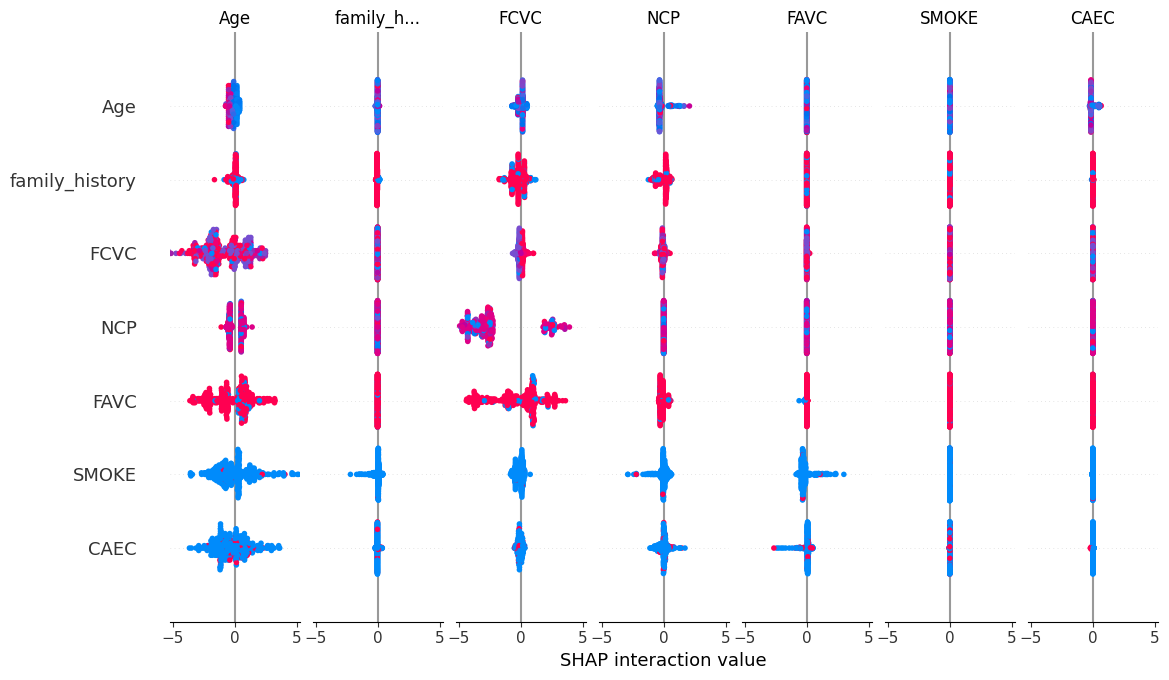

In [15]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# média absoluta entre classes
import numpy as np

shap.summary_plot(shap_values, X_test)

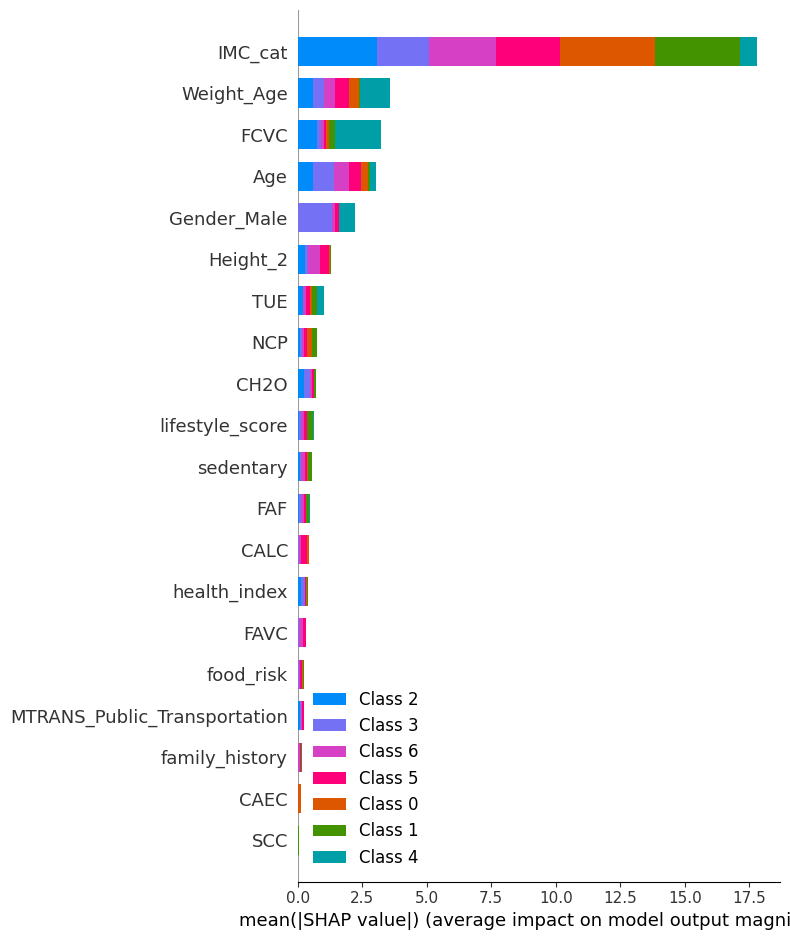

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [17]:
#Novo Teste

X_sem_bmi = X.drop(columns=["IMC",
    "IMC_cat",
    "Weight",
    "Height",
    "Weight_Age"])

X_train, X_test, y_train, y_test = train_test_split(
    X_sem_bmi, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8817966903073287


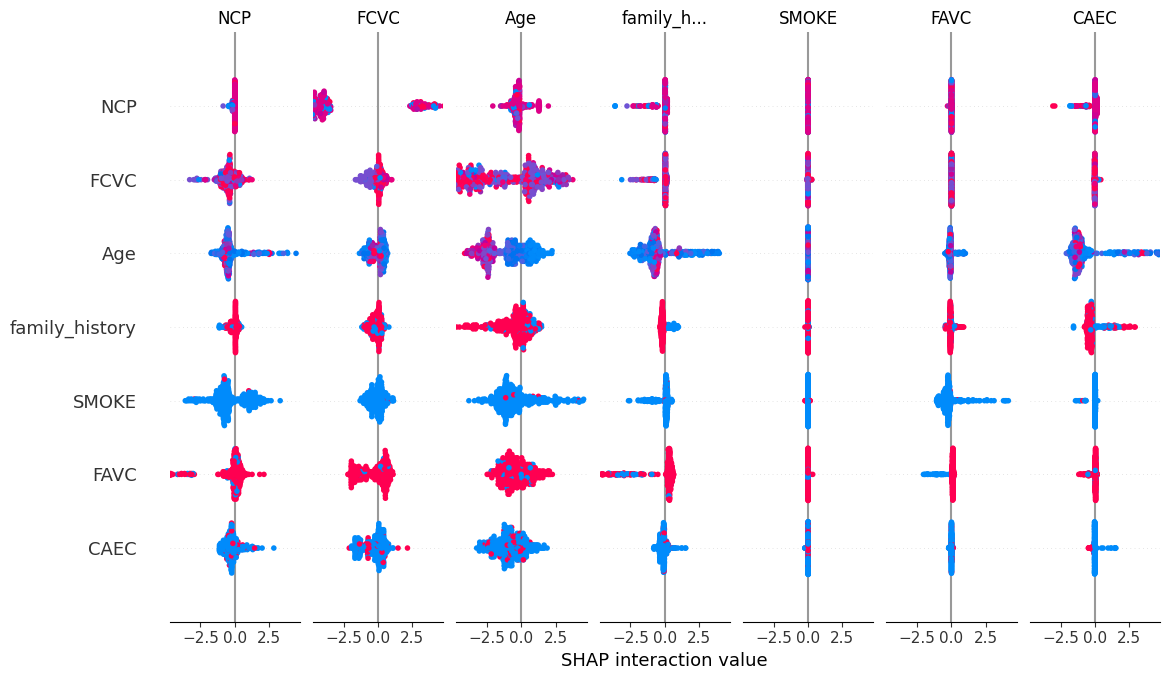

In [18]:

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# média absoluta entre classes
import numpy as np

shap.summary_plot(shap_values, X_test)

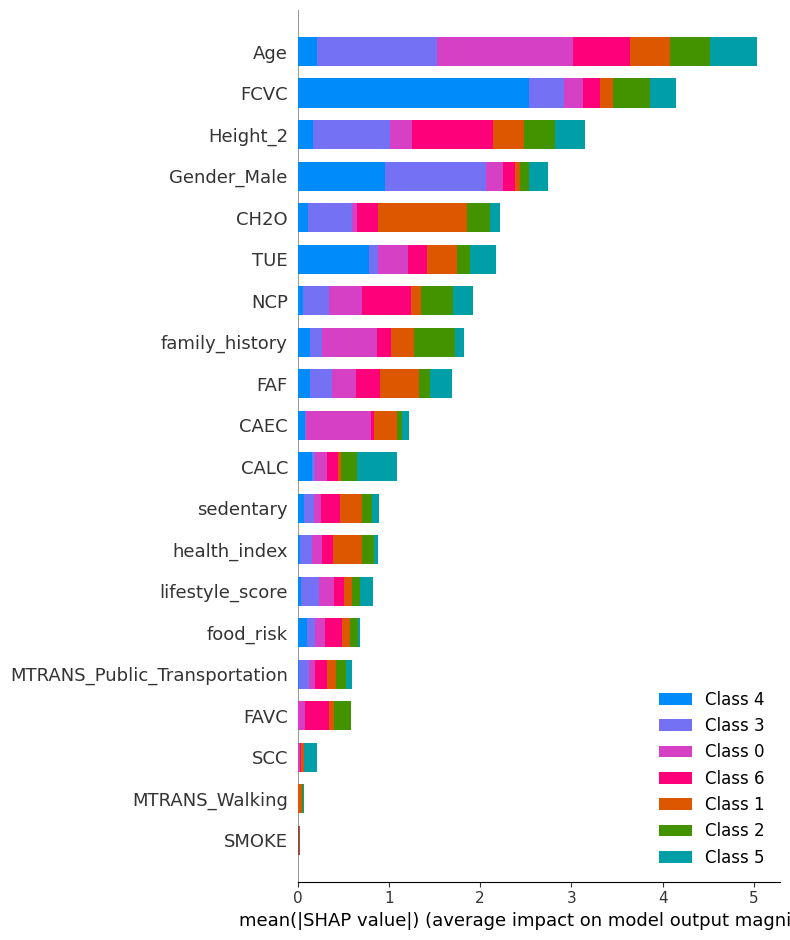

In [19]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [20]:
import joblib
from google.cloud import storage

# 1. SALVAR MODELO LOCALMENTE

joblib.dump(model, "xgb_obesity_model.pkl")

# 2. CONECTAR NO GCS

client = storage.Client()
bucket = client.bucket("tech-challenge-4-obesity")

# 3. ENVIAR PARA O STORAGE

blob = bucket.blob(
    "models/xgb_obesity_model.pkl"
)

blob.upload_from_filename(
    "xgb_obesity_model.pkl"
)

print("Modelo enviado com sucesso.")

Modelo enviado com sucesso.


In [ ]:
# Colunas Usadas no Modelo
print(X_sem_bmi.columns.tolist())

In [23]:
#Salvando colunas usadas no modelo

# 1. SALVAR MODELO LOCALMENTE
joblib.dump(
    X_sem_bmi.columns.tolist(),
    "feature_columns.pkl"
)

# 2. CONECTAR NO GCS
client = storage.Client()
bucket = client.bucket("tech-challenge-4-obesity")

# 3. ENVIAR PARA O STORAGE

blob = bucket.blob(
    "models/feature_columns.pkl"
)
blob.upload_from_filename(
    "feature_columns.pkl"
)
print("Arquivo PKL enviado com sucesso.")

Modelo enviado com sucesso.


In [75]:
amostra = X_test.sample(20, random_state=42)
model.predict(amostra)

array([3, 2, 5, 2, 6, 0, 0, 2, 3, 0, 4, 5, 1, 3, 2, 3, 5, 0, 6, 0])

In [76]:
y_test.loc[amostra.index]

,Obesity
1601,3
1400,2
791,5
1381,2
1161,6
561,0
291,0
387,2
1514,3
710,0


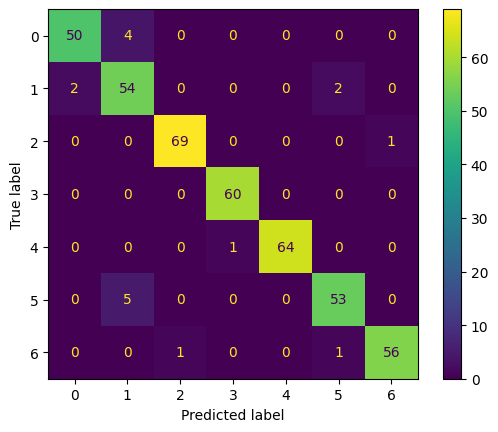

In [77]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

In [78]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        54
           1       0.86      0.93      0.89        58
           2       0.99      0.99      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.95      0.91      0.93        58
           6       0.98      0.97      0.97        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423

